Input FWHM = 1.8 keV
Input sigma = 0.7643896348765511 keV

TTree entries = 100000

RAW GEANT4 PHOTOPEAK
Number of entries = 3686
Minimum = 661.9999999999998 keV
Maximum = 662.0000000000002 keV
Mean    = 662.0 keV
Std Dev = 3.232515775650053e-14 keV

AFTER DETECTOR SMEARING
Number of entries = 3686
Minimum = 659.6154035013581 keV
Maximum = 664.8443685973812 keV
Mean    = 662.0122608353277 keV
Std Dev = 0.7716455682678174 keV

Histogram counts = 3686
Maximum bin count = 221

GAUSSIAN FIT RESULTS
Peak mean  = 662.0058 keV
Sigma      = 0.7647 keV
FWHM       = 1.8008 keV
Resolution = 0.2720 %


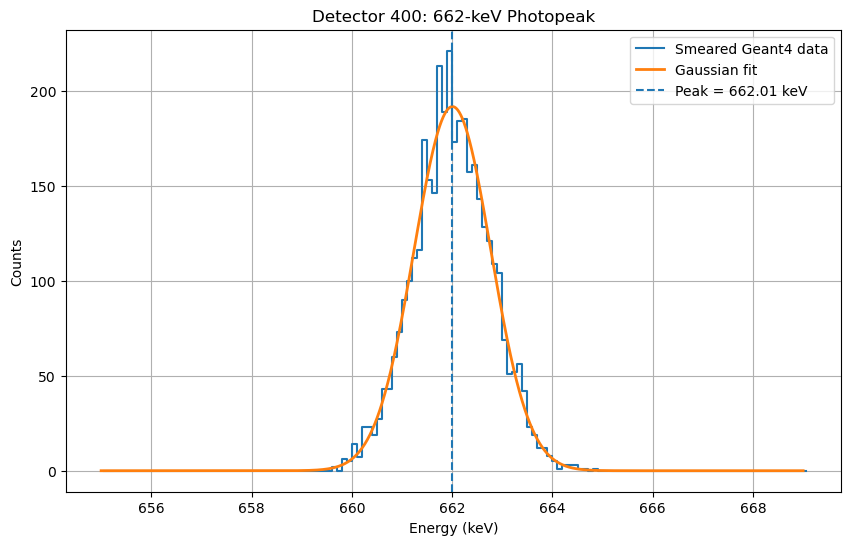

In [7]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# SETTINGS
# ============================================================

file_path = "/root/geant4/detector/Lung_ICRP/Detector_400.root"
tree_name = "t"

# From your diagnostic:
# 662-keV records were found at vlm = 1, pdg = 22
selected_volume = 1
selected_pdg = 22

# Incident gamma energy
E0 = 662.0  # keV

# ------------------------------------------------------------
# EXAMPLE detector resolution
#
# IMPORTANT:
# 1.8 keV is an ASSUMED value here.
# Replace it with the measured/manufacturer FWHM of your HPGe.
# ------------------------------------------------------------

FWHM_input = 1.8  # keV

sigma_input = FWHM_input / 2.35482

print("Input FWHM =", FWHM_input, "keV")
print("Input sigma =", sigma_input, "keV")


# ============================================================
# OPEN ROOT FILE
# ============================================================

f = ROOT.TFile.Open(file_path)

if not f or f.IsZombie():
    raise OSError("Could not open ROOT file")

tree = f.Get(tree_name)

if not tree:
    raise KeyError(f"TTree '{tree_name}' not found")

print("\nTTree entries =", tree.GetEntries())


# ============================================================
# EXTRACT RAW 662-keV PHOTOPEAK
# ============================================================

E_raw = []

for event in tree:

    n = min(
        len(event.et),
        len(event.vlm),
        len(event.pdg)
    )

    for i in range(n):

        E = float(event.et[i])
        vlm = int(event.vlm[i])
        pdg = int(event.pdg[i])

        if vlm != selected_volume:
            continue

        if pdg != selected_pdg:
            continue

        # Select photopeak
        if 650.0 <= E <= 670.0:
            E_raw.append(E)


f.Close()

E_raw = np.asarray(E_raw, dtype=float)


# ============================================================
# CHECK RAW DATA
# ============================================================

print("\n========================================")
print("RAW GEANT4 PHOTOPEAK")
print("========================================")

print("Number of entries =", len(E_raw))

if len(E_raw) == 0:
    raise RuntimeError(
        "No 650-670 keV events found. "
        "Check selected_volume and selected_pdg."
    )

print("Minimum =", np.min(E_raw), "keV")
print("Maximum =", np.max(E_raw), "keV")
print("Mean    =", np.mean(E_raw), "keV")
print("Std Dev =", np.std(E_raw), "keV")


# ============================================================
# APPLY GAUSSIAN DETECTOR SMEARING
# ============================================================

rng = np.random.default_rng(12345)

E_smeared = rng.normal(
    loc=E_raw,
    scale=sigma_input
)

print("\n========================================")
print("AFTER DETECTOR SMEARING")
print("========================================")

print("Number of entries =", len(E_smeared))
print("Minimum =", np.min(E_smeared), "keV")
print("Maximum =", np.max(E_smeared), "keV")
print("Mean    =", np.mean(E_smeared), "keV")
print("Std Dev =", np.std(E_smeared), "keV")


# ============================================================
# MAKE HISTOGRAM
# ============================================================

bin_width = 0.10  # keV

edges = np.arange(
    655.0,
    669.0 + bin_width,
    bin_width
)

counts, edges = np.histogram(
    E_smeared,
    bins=edges
)

centers = 0.5 * (
    edges[:-1] + edges[1:]
)

print("\nHistogram counts =", np.sum(counts))
print("Maximum bin count =", np.max(counts))


# ============================================================
# GAUSSIAN FUNCTION
# ============================================================

def gaussian(x, A, mu, sigma):

    return A * np.exp(
        -0.5 * ((x - mu) / sigma)**2
    )


# ============================================================
# FIT ONLY THE PHOTOPEAK REGION
# ============================================================

fit_mask = (
    (centers >= 658.0) &
    (centers <= 666.0)
)

x_fit_data = centers[fit_mask]
y_fit_data = counts[fit_mask]


# Initial estimates
A0 = np.max(y_fit_data)
mu0 = np.mean(E_smeared)
sigma0 = np.std(E_smeared)

p0 = [
    A0,
    mu0,
    sigma0
]

# Bounds prevent unphysical solutions
bounds = (
    [0, 660, 0.01],
    [np.inf, 664, 5.0]
)


popt, pcov = curve_fit(
    gaussian,
    x_fit_data,
    y_fit_data,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)


A_fit, mu_fit, sigma_fit = popt

sigma_fit = abs(sigma_fit)


# ============================================================
# CALCULATE FWHM AND RESOLUTION
# ============================================================

FWHM_fit = 2.35482 * sigma_fit

resolution_percent = (
    FWHM_fit / mu_fit
) * 100


print("\n========================================")
print("GAUSSIAN FIT RESULTS")
print("========================================")

print(f"Peak mean  = {mu_fit:.4f} keV")
print(f"Sigma      = {sigma_fit:.4f} keV")
print(f"FWHM       = {FWHM_fit:.4f} keV")
print(f"Resolution = {resolution_percent:.4f} %")


# ============================================================
# PLOT
# ============================================================

x_curve = np.linspace(
    655,
    669,
    2000
)

y_curve = gaussian(
    x_curve,
    *popt
)


plt.figure(figsize=(10,6))

plt.step(
    centers,
    counts,
    where="mid",
    label="Smeared Geant4 data"
)

plt.plot(
    x_curve,
    y_curve,
    linewidth=2,
    label="Gaussian fit"
)

plt.axvline(
    mu_fit,
    linestyle="--",
    label=f"Peak = {mu_fit:.2f} keV"
)

plt.xlabel("Energy (keV)")
plt.ylabel("Counts")

plt.title(
    "Detector 400: 662-keV Photopeak"
)

plt.grid(True)
plt.legend()

plt.show()

TTree entries = 100000

RAW GEANT4
Number of events = 3686
Mean energy      = 662.0 keV
Std Dev          = 3.232515775650053e-14 keV

THEORETICAL HPGe FANO RESOLUTION
E peak       = 662.0000 keV
epsilon      = 2.960 eV/pair
Fano factor  = 0.130

Electron-hole pairs = 223649
Sigma N      = 170.512 pairs
Sigma E      = 0.5047 keV
FWHM         = 1.1885 keV
Resolution   = 0.1795 %

GAUSSIAN FIT TO FANO RESPONSE
Mean       = 662.0052 keV
Sigma      = 0.5034 keV
FWHM       = 1.1854 keV
Resolution = 0.1791 %


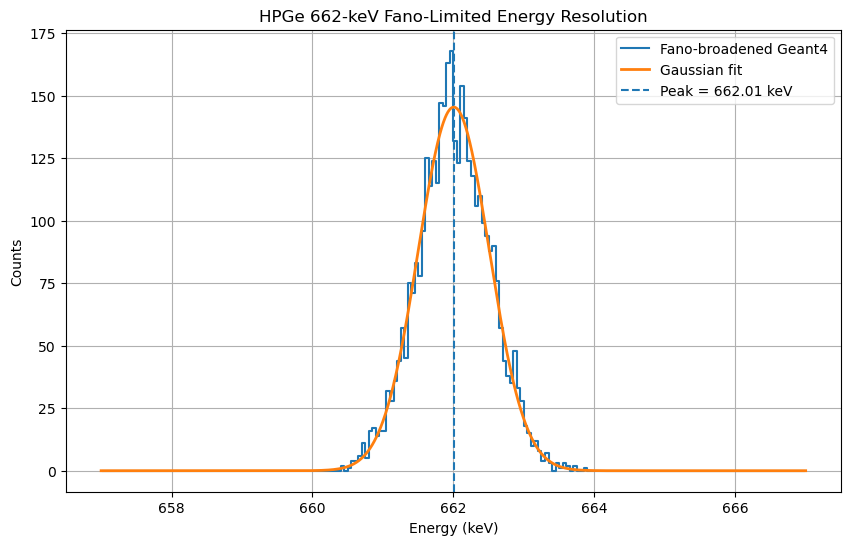

In [11]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# SETTINGS
# ============================================================

file_path = "/root/geant4/detector/Lung_ICRP/Detector_400.root"
tree_name = "t"

# From your diagnostic
selected_volume = 1
selected_pdg = 22

# ============================================================
# HPGe PHYSICS PARAMETERS
# ============================================================

# Mean energy to create one electron-hole pair in Ge
epsilon_eV = 2.96       # eV

# Fano factor for Ge
Fano = 0.13

# 2*sqrt(2*ln(2))
GAUSS_TO_FWHM = 2.35482


# ============================================================
# OPEN ROOT FILE
# ============================================================

f = ROOT.TFile.Open(file_path)

if not f or f.IsZombie():
    raise OSError("Could not open ROOT file")

tree = f.Get(tree_name)

if not tree:
    raise KeyError(f"TTree '{tree_name}' not found")

print("TTree entries =", tree.GetEntries())


# ============================================================
# EXTRACT RAW GEANT4 PHOTOPEAK
# ============================================================

E_raw = []

for event in tree:

    n = min(
        len(event.et),
        len(event.vlm),
        len(event.pdg)
    )

    for i in range(n):

        E = float(event.et[i])
        vlm = int(event.vlm[i])
        pdg = int(event.pdg[i])

        if vlm != selected_volume:
            continue

        if pdg != selected_pdg:
            continue

        # Select 662-keV photopeak
        if 650.0 <= E <= 670.0:
            E_raw.append(E)

f.Close()

E_raw = np.asarray(E_raw, dtype=float)

if len(E_raw) == 0:
    raise RuntimeError("No photopeak events found.")


# ============================================================
# RAW GEANT4 RESULTS
# ============================================================

print("\n====================================")
print("RAW GEANT4")
print("====================================")

print("Number of events =", len(E_raw))
print("Mean energy      =", np.mean(E_raw), "keV")
print("Std Dev          =", np.std(E_raw), "keV")


# ============================================================
# CALCULATE FANO-LIMITED RESOLUTION
# ============================================================

E_peak_keV = np.mean(E_raw)

# Convert energy to eV
E_peak_eV = E_peak_keV * 1000.0

# Number of electron-hole pairs
N_pairs = E_peak_eV / epsilon_eV

# Statistical fluctuation in number of pairs
sigma_N = np.sqrt(Fano * N_pairs)

# Energy sigma
sigma_E_eV = epsilon_eV * sigma_N

# Equivalent:
# sigma_E_eV = sqrt(F * epsilon * E)

sigma_E_keV = sigma_E_eV / 1000.0

# FWHM
FWHM_Fano_keV = GAUSS_TO_FWHM * sigma_E_keV

# Resolution
resolution_Fano = (
    FWHM_Fano_keV / E_peak_keV
) * 100.0


print("\n====================================")
print("THEORETICAL HPGe FANO RESOLUTION")
print("====================================")

print(f"E peak       = {E_peak_keV:.4f} keV")
print(f"epsilon      = {epsilon_eV:.3f} eV/pair")
print(f"Fano factor  = {Fano:.3f}")

print(f"\nElectron-hole pairs = {N_pairs:.0f}")

print(f"Sigma N      = {sigma_N:.3f} pairs")
print(f"Sigma E      = {sigma_E_keV:.4f} keV")

print(f"FWHM         = {FWHM_Fano_keV:.4f} keV")
print(f"Resolution   = {resolution_Fano:.4f} %")


# ============================================================
# GENERATE FANO-BROADENED DETECTOR RESPONSE
# ============================================================

rng = np.random.default_rng(12345)

# IMPORTANT:
# sigma depends on each deposited energy
#
# sigma(E) = sqrt(F * epsilon * E)
#
# E_raw is in keV
# Convert to eV for calculation

sigma_each_keV = (
    np.sqrt(
        Fano *
        epsilon_eV *
        E_raw * 1000.0
    )
    / 1000.0
)

E_detector = rng.normal(
    loc=E_raw,
    scale=sigma_each_keV
)


# ============================================================
# HISTOGRAM
# ============================================================

bin_width = 0.05

edges = np.arange(
    657,
    667 + bin_width,
    bin_width
)

counts, edges = np.histogram(
    E_detector,
    bins=edges
)

centers = 0.5 * (
    edges[:-1] + edges[1:]
)


# ============================================================
# GAUSSIAN FUNCTION
# ============================================================

def gaussian(x, A, mu, sigma):

    return A * np.exp(
        -0.5 * ((x-mu)/sigma)**2
    )


# ============================================================
# GAUSSIAN FIT
# ============================================================

fit_mask = (
    (centers >= 659) &
    (centers <= 665)
)

xdata = centers[fit_mask]
ydata = counts[fit_mask]

p0 = [
    np.max(ydata),
    E_peak_keV,
    sigma_E_keV
]

bounds = (
    [0, 660, 0.01],
    [np.inf, 664, 5]
)

popt, pcov = curve_fit(
    gaussian,
    xdata,
    ydata,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

A_fit, mu_fit, sigma_fit = popt

sigma_fit = abs(sigma_fit)

FWHM_fit = GAUSS_TO_FWHM * sigma_fit

resolution_fit = (
    FWHM_fit / mu_fit
) * 100


# ============================================================
# FIT RESULTS
# ============================================================

print("\n====================================")
print("GAUSSIAN FIT TO FANO RESPONSE")
print("====================================")

print(f"Mean       = {mu_fit:.4f} keV")
print(f"Sigma      = {sigma_fit:.4f} keV")
print(f"FWHM       = {FWHM_fit:.4f} keV")
print(f"Resolution = {resolution_fit:.4f} %")


# ============================================================
# PLOT
# ============================================================

xfit = np.linspace(
    657,
    667,
    2000
)

plt.figure(figsize=(10,6))

plt.step(
    centers,
    counts,
    where="mid",
    label="Fano-broadened Geant4"
)

plt.plot(
    xfit,
    gaussian(xfit, *popt),
    linewidth=2,
    label="Gaussian fit"
)

plt.axvline(
    mu_fit,
    linestyle="--",
    label=f"Peak = {mu_fit:.2f} keV"
)

plt.xlabel("Energy (keV)")
plt.ylabel("Counts")

plt.title(
    "HPGe 662-keV Fano-Limited Energy Resolution"
)

plt.grid(True)
plt.legend()

plt.show()

Number of simulated events = 100000

DETECTOR 400
Total events = 100000
Events with Edep > 0 = 31039
Events with Edep = 0 = 68961
Maximum event Edep = 662.0000000000002 keV


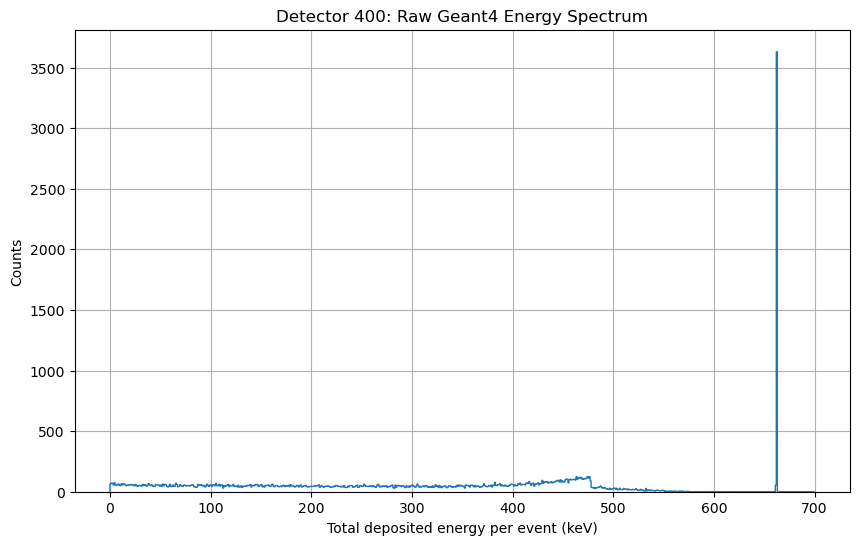


640-670 keV REGION
Number of events = 3686
Mean = 662.0 keV
Std = 3.232515775650053e-14 keV
Minimum = 661.9999999999998
Maximum = 662.0000000000002


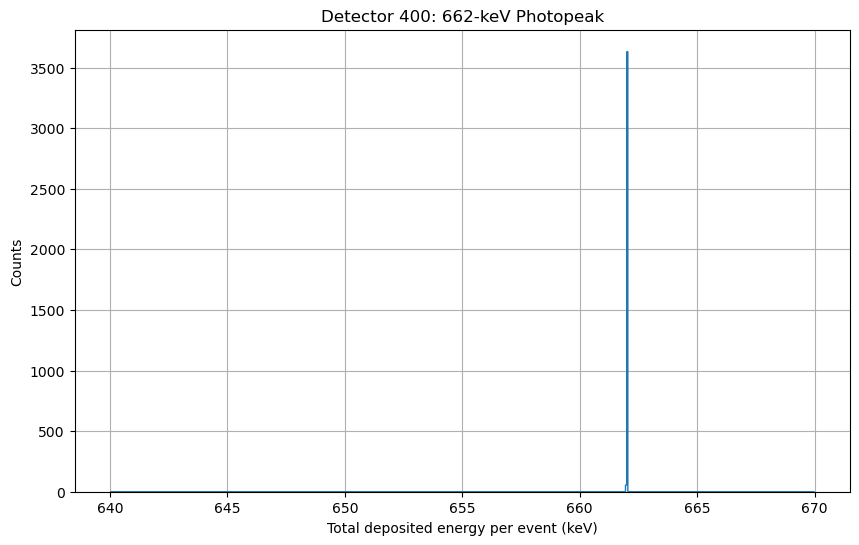

In [13]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

file_path = "/root/geant4/detector/Lung_ICRP/Detector_400.root"
tree_name = "t"

detector_volume = 400

# ============================================================
# OPEN ROOT FILE
# ============================================================

f = ROOT.TFile.Open(file_path)

if not f or f.IsZombie():
    raise OSError("Cannot open ROOT file")

tree = f.Get(tree_name)

if not tree:
    raise KeyError("TTree not found")

print("Number of simulated events =", tree.GetEntries())


# ============================================================
# SUM ENERGY DEPOSITION PER EVENT
# ============================================================

event_edep = []

for event in tree:

    E_sum = 0.0

    n = min(
        len(event.vlm),
        len(event.de)
    )

    for i in range(n):

        if int(event.vlm[i]) == detector_volume:

            de = float(event.de[i])

            if de > 0:
                E_sum += de

    event_edep.append(E_sum)


f.Close()

event_edep = np.asarray(event_edep)


# ============================================================
# BASIC INFORMATION
# ============================================================

print("\n====================================")
print("DETECTOR 400")
print("====================================")

print("Total events =", len(event_edep))

print(
    "Events with Edep > 0 =",
    np.sum(event_edep > 0)
)

print(
    "Events with Edep = 0 =",
    np.sum(event_edep == 0)
)

print(
    "Maximum event Edep =",
    np.max(event_edep),
    "keV"
)


# ============================================================
# ONLY EVENTS THAT DEPOSIT ENERGY
# ============================================================

hit_energy = event_edep[event_edep > 0]


# ============================================================
# FULL ENERGY SPECTRUM
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    hit_energy,
    bins=700,
    range=(0,700),
    histtype="step"
)

plt.xlabel("Total deposited energy per event (keV)")
plt.ylabel("Counts")

plt.title(
    "Detector 400: Raw Geant4 Energy Spectrum"
)

plt.grid(True)

plt.show()


# ============================================================
# LOOK AT PHOTOPEAK REGION
# ============================================================

photopeak = event_edep[
    (event_edep >= 640) &
    (event_edep <= 670)
]

print("\n====================================")
print("640-670 keV REGION")
print("====================================")

print(
    "Number of events =",
    len(photopeak)
)

if len(photopeak) > 0:

    print(
        "Mean =",
        np.mean(photopeak),
        "keV"
    )

    print(
        "Std =",
        np.std(photopeak),
        "keV"
    )

    print(
        "Minimum =",
        np.min(photopeak)
    )

    print(
        "Maximum =",
        np.max(photopeak)
    )


# ============================================================
# HIGH-RESOLUTION PHOTOPEAK PLOT
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    photopeak,
    bins=600,
    range=(640,670),
    histtype="step"
)

plt.xlabel(
    "Total deposited energy per event (keV)"
)

plt.ylabel("Counts")

plt.title(
    "Detector 400: 662-keV Photopeak"
)

plt.grid(True)

plt.show()

Number of simulated events = 100000

RAW GEANT4 DETECTOR SPECTRUM
Total events             = 100000
Events with Edep > 0     = 31039
Events with Edep = 0     = 68961
Maximum deposited energy = 662.0000000000002 keV

RAW 662-keV PHOTOPEAK
Number of events = 3686
Mean             = 662.0 keV
Std Dev          = 3.232515775650053e-14 keV

THEORETICAL FANO LIMIT AT 662 keV
Fano factor F       = 0.1300
Pair energy epsilon = 2.9600 eV
Sigma               = 0.5047 keV
FWHM                = 1.1885 keV
Resolution          = 0.1795 %


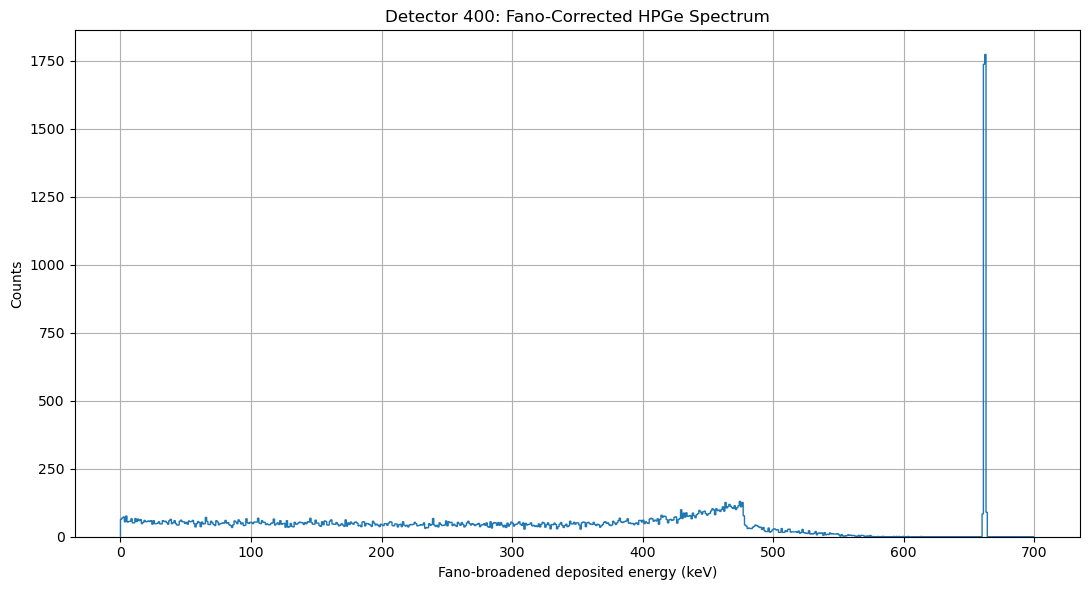


FANO-BROADENED PHOTOPEAK
Number of events = 3686
Mean = 661.9980424799252 keV
Std = 0.5024244549418753 keV

GAUSSIAN FIT RESULTS
Peak energy = 662.0058 keV
Sigma       = 0.5044 keV
FWHM        = 1.1877 keV
Resolution  = 0.1794 %
Left FWHM   = 661.4120 keV
Right FWHM  = 662.5997 keV


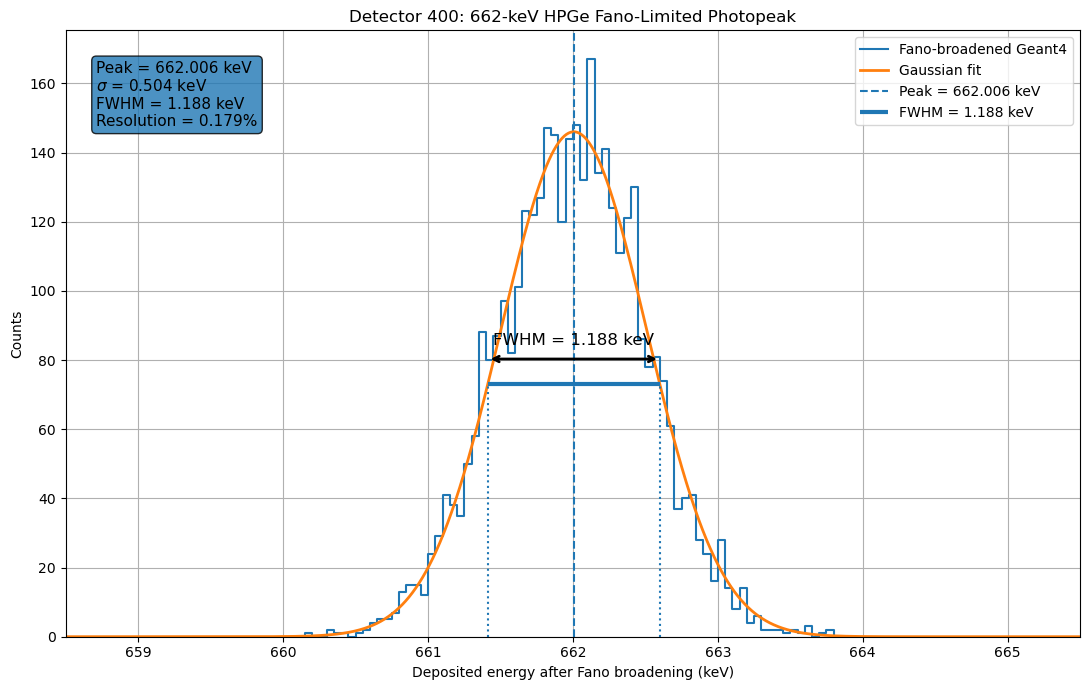

In [14]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# 1. SETTINGS
# ============================================================

file_path = "/root/geant4/detector/Lung_ICRP/Detector_400.root"
tree_name = "t"

# Actual HPGe detector volume
detector_volume = 400

# ------------------------------------------------------------
# Germanium detector parameters
# ------------------------------------------------------------

# Mean energy required to produce one electron-hole pair
epsilon_eV = 2.96       # eV

# Fano factor for germanium
Fano = 0.13

GAUSS_TO_FWHM = 2.35482

# Random seed for reproducibility
rng = np.random.default_rng(12345)


# ============================================================
# 2. OPEN ROOT FILE
# ============================================================

f = ROOT.TFile.Open(file_path)

if not f or f.IsZombie():
    raise OSError("Cannot open ROOT file.")

tree = f.Get(tree_name)

if not tree:
    raise KeyError(f"TTree '{tree_name}' not found.")

print("Number of simulated events =", tree.GetEntries())


# ============================================================
# 3. TOTAL ENERGY DEPOSITION PER EVENT IN DETECTOR 400
# ============================================================

event_edep = []

for event in tree:

    E_sum = 0.0

    n = min(
        len(event.vlm),
        len(event.de)
    )

    for i in range(n):

        if int(event.vlm[i]) != detector_volume:
            continue

        de = float(event.de[i])

        if de > 0:
            E_sum += de

    event_edep.append(E_sum)


f.Close()

event_edep = np.asarray(event_edep, dtype=float)


# ============================================================
# 4. RAW GEANT4 INFORMATION
# ============================================================

hit_energy = event_edep[event_edep > 0]

print("\n==========================================")
print("RAW GEANT4 DETECTOR SPECTRUM")
print("==========================================")

print("Total events             =", len(event_edep))
print("Events with Edep > 0     =", len(hit_energy))
print("Events with Edep = 0     =", np.sum(event_edep == 0))
print("Maximum deposited energy =", np.max(hit_energy), "keV")


# ============================================================
# 5. RAW 662-keV PHOTOPEAK
# ============================================================

raw_photopeak = hit_energy[
    (hit_energy >= 640.0) &
    (hit_energy <= 670.0)
]

print("\n==========================================")
print("RAW 662-keV PHOTOPEAK")
print("==========================================")

print("Number of events =", len(raw_photopeak))
print("Mean             =", np.mean(raw_photopeak), "keV")
print("Std Dev          =", np.std(raw_photopeak), "keV")


# ============================================================
# 6. FANO BROADENING
# ============================================================
#
# For Ge:
#
# sigma_E^2 = F * epsilon * E
#
# epsilon is in eV
# E must therefore first be converted from keV -> eV.
#
# sigma_E(eV) = sqrt(F * epsilon(eV) * E(eV))
#
# ============================================================

E_eV = hit_energy * 1000.0

sigma_Fano_eV = np.sqrt(
    Fano * epsilon_eV * E_eV
)

sigma_Fano_keV = (
    sigma_Fano_eV / 1000.0
)


# ------------------------------------------------------------
# Generate detector-measured energies
# ------------------------------------------------------------

E_fano = rng.normal(
    loc=hit_energy,
    scale=sigma_Fano_keV
)


# ============================================================
# 7. THEORETICAL FANO RESOLUTION AT 662 keV
# ============================================================

E0_keV = 662.0
E0_eV = E0_keV * 1000.0

sigma_theory_keV = (
    np.sqrt(
        Fano *
        epsilon_eV *
        E0_eV
    )
    / 1000.0
)

FWHM_theory_keV = (
    GAUSS_TO_FWHM *
    sigma_theory_keV
)

resolution_theory = (
    FWHM_theory_keV /
    E0_keV
) * 100.0


print("\n==========================================")
print("THEORETICAL FANO LIMIT AT 662 keV")
print("==========================================")

print(f"Fano factor F       = {Fano:.4f}")
print(f"Pair energy epsilon = {epsilon_eV:.4f} eV")
print(f"Sigma               = {sigma_theory_keV:.4f} keV")
print(f"FWHM                = {FWHM_theory_keV:.4f} keV")
print(f"Resolution          = {resolution_theory:.4f} %")


# ============================================================
# 8. FULL FANO-CORRECTED SPECTRUM
# ============================================================

plt.figure(figsize=(11, 6))

plt.hist(
    E_fano,
    bins=700,
    range=(0, 700),
    histtype="step"
)

plt.xlabel(
    "Fano-broadened deposited energy (keV)"
)

plt.ylabel("Counts")

plt.title(
    "Detector 400: Fano-Corrected HPGe Spectrum"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 9. SELECT BROADENED PHOTOPEAK
# ============================================================

photopeak_fano = E_fano[
    (E_fano >= 657.0) &
    (E_fano <= 667.0)
]

print("\n==========================================")
print("FANO-BROADENED PHOTOPEAK")
print("==========================================")

print(
    "Number of events =",
    len(photopeak_fano)
)

print(
    "Mean =",
    np.mean(photopeak_fano),
    "keV"
)

print(
    "Std =",
    np.std(photopeak_fano),
    "keV"
)


# ============================================================
# 10. HIGH-RESOLUTION HISTOGRAM
# ============================================================

bin_width = 0.05  # keV

edges = np.arange(
    657.0,
    667.0 + bin_width,
    bin_width
)

counts, edges = np.histogram(
    photopeak_fano,
    bins=edges
)

centers = (
    edges[:-1] + edges[1:]
) / 2.0


# ============================================================
# 11. GAUSSIAN FUNCTION
# ============================================================

def gaussian(x, A, mu, sigma):

    return A * np.exp(
        -0.5 *
        ((x - mu) / sigma)**2
    )


# ============================================================
# 12. FIT THE PHOTOPEAK
# ============================================================

fit_mask = (
    (centers >= 659.0) &
    (centers <= 665.0)
)

xdata = centers[fit_mask]
ydata = counts[fit_mask]


# Initial guesses
A0 = np.max(ydata)
mu0 = 662.0
sigma0 = sigma_theory_keV

p0 = [
    A0,
    mu0,
    sigma0
]


bounds = (
    [0, 660.0, 0.01],
    [np.inf, 664.0, 5.0]
)


popt, pcov = curve_fit(
    gaussian,
    xdata,
    ydata,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)


A_fit, mu_fit, sigma_fit = popt

sigma_fit = abs(sigma_fit)


# ============================================================
# 13. CALCULATE FWHM FROM GAUSSIAN FIT
# ============================================================

FWHM_fit = (
    GAUSS_TO_FWHM *
    sigma_fit
)

resolution_fit = (
    FWHM_fit /
    mu_fit
) * 100.0


# FWHM boundaries
E_left = (
    mu_fit -
    FWHM_fit / 2.0
)

E_right = (
    mu_fit +
    FWHM_fit / 2.0
)

# Half maximum
half_max = (
    A_fit / 2.0
)


# ============================================================
# 14. PRINT FINAL RESULTS
# ============================================================

print("\n==========================================")
print("GAUSSIAN FIT RESULTS")
print("==========================================")

print(f"Peak energy = {mu_fit:.4f} keV")

print(
    f"Sigma       = "
    f"{sigma_fit:.4f} keV"
)

print(
    f"FWHM        = "
    f"{FWHM_fit:.4f} keV"
)

print(
    f"Resolution  = "
    f"{resolution_fit:.4f} %"
)

print(
    f"Left FWHM   = "
    f"{E_left:.4f} keV"
)

print(
    f"Right FWHM  = "
    f"{E_right:.4f} keV"
)


# ============================================================
# 15. PHOTOPEAK PLOT WITH FWHM CLEARLY MARKED
# ============================================================

xfit = np.linspace(
    657.0,
    667.0,
    3000
)

yfit = gaussian(
    xfit,
    *popt
)


plt.figure(figsize=(11, 7))


# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

plt.step(
    centers,
    counts,
    where="mid",
    linewidth=1.5,
    label="Fano-broadened Geant4"
)


# ------------------------------------------------------------
# Gaussian fit
# ------------------------------------------------------------

plt.plot(
    xfit,
    yfit,
    linewidth=2,
    label="Gaussian fit"
)


# ------------------------------------------------------------
# Peak center
# ------------------------------------------------------------

plt.axvline(
    mu_fit,
    linestyle="--",
    linewidth=1.5,
    label=f"Peak = {mu_fit:.3f} keV"
)


# ------------------------------------------------------------
# Half maximum line = FWHM
# ------------------------------------------------------------

plt.hlines(
    half_max,
    E_left,
    E_right,
    linewidth=3,
    label=f"FWHM = {FWHM_fit:.3f} keV"
)


# ------------------------------------------------------------
# Left FWHM boundary
# ------------------------------------------------------------

plt.vlines(
    E_left,
    0,
    half_max,
    linestyle=":",
    linewidth=1.5
)


# ------------------------------------------------------------
# Right FWHM boundary
# ------------------------------------------------------------

plt.vlines(
    E_right,
    0,
    half_max,
    linestyle=":",
    linewidth=1.5
)


# ------------------------------------------------------------
# FWHM double arrow
# ------------------------------------------------------------

arrow_y = half_max * 1.10

plt.annotate(
    "",
    xy=(E_right, arrow_y),
    xytext=(E_left, arrow_y),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=2
    )
)


# ------------------------------------------------------------
# FWHM text
# ------------------------------------------------------------

plt.text(
    mu_fit,
    arrow_y * 1.05,
    f"FWHM = {FWHM_fit:.3f} keV",
    horizontalalignment="center",
    fontsize=12
)


# ------------------------------------------------------------
# Resolution text box
# ------------------------------------------------------------

result_text = (
    f"Peak = {mu_fit:.3f} keV\n"
    f"$\\sigma$ = {sigma_fit:.3f} keV\n"
    f"FWHM = {FWHM_fit:.3f} keV\n"
    f"Resolution = {resolution_fit:.3f}%"
)

plt.text(
    0.03,
    0.95,
    result_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)


plt.xlabel(
    "Deposited energy after Fano broadening (keV)"
)

plt.ylabel("Counts")

plt.title(
    "Detector 400: 662-keV HPGe Fano-Limited Photopeak"
)

plt.xlim(
    658.5,
    665.5
)

plt.ylim(
    bottom=0
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()